<a href="https://colab.research.google.com/github/sabiha311/COMP-ANALY-HIGH-TP-BIOMED-DATA/blob/Assignment-5/Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import os

# List all files in /content/
for f in os.listdir('/content/'):
    print(f)


.config
Human-PPI.txt
protein-list2.txt
protein-list1.txt
sample_data


Average Clustering Coefficient: 0.20981404670001005


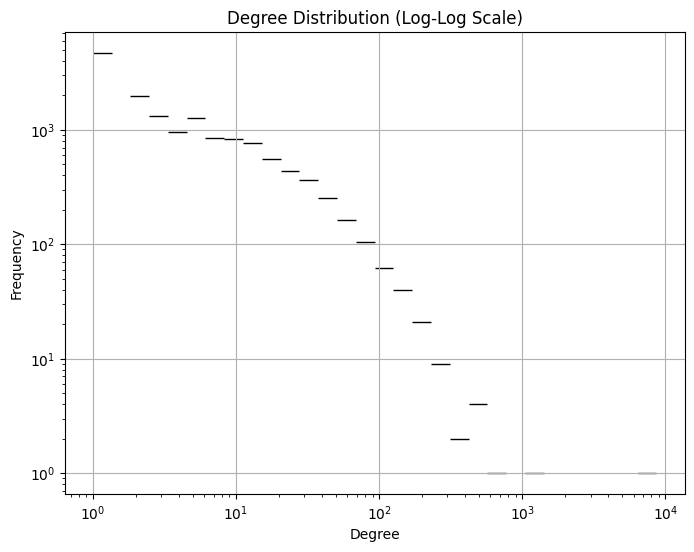

In [ ]:
# Install required packages (once per session)
!pip install networkx scipy matplotlib seaborn

#  Import libraries
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

#  Define actual file paths
interaction_file = '/content/Human-PPI.txt'
set1_file = '/content/protein-list1.txt'
set2_file = '/content/protein-list2.txt'

#  Load and clean interaction data
df = pd.read_csv(interaction_file, sep='\t', header=0, names=["ProteinA", "ProteinB"])
df = df.dropna()
df = df[df.columns[:2]]

#  Build the protein interaction network
G = nx.Graph()
G.add_edges_from(df.itertuples(index=False, name=None))

#  Calculate degrees and clustering coefficients
degrees = dict(G.degree())
clustering = nx.clustering(G)
avg_clustering = nx.average_clustering(G)
print("Average Clustering Coefficient:", avg_clustering)

#  Plot degree distribution (log-log scale)
degree_values = list(degrees.values())
plt.figure(figsize=(8, 6))
sns.histplot(degree_values, bins=30, kde=False, log_scale=(True, True), color='orange', edgecolor='black')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.title('Degree Distribution (Log-Log Scale)')
plt.grid(True)
plt.show()

# Load protein sets
with open(set1_file) as f:
    set1 = set(f.read().splitlines())

with open(set2_file) as f:
    set2 = set(f.read().splitlines())

#  Compute all-pairs shortest paths
lengths = dict(nx.all_pairs_shortest_path_length(G))

def get_path_lengths(protein_set):
    path_lengths = []
    for p1 in protein_set:
        for p2 in protein_set:
            if p1 != p2 and p1 in lengths and p2 in lengths[p1]:
                path_lengths.append(lengths[p1][p2])
    return path_lengths

path_lengths_1 = get_path_lengths(set1)
path_lengths_2 = get_path_lengths(set2)

#  Plot path length distributions
plt.figure(figsize=(10, 5))
sns.kdeplot(path_lengths_1, label='Protein List 1', shade=True)
sns.kdeplot(path_lengths_2, label='Protein List 2', shade=True)
plt.xlabel('Shortest Path Length')
plt.ylabel('Density')
plt.title('Shortest Path Length Distribution')
plt.legend()
plt.grid(True)
plt.show()

#  Perform Wilcoxon test
min_len = min(len(path_lengths_1), len(path_lengths_2))
stat, p_value = wilcoxon(path_lengths_1[:min_len], path_lengths_2[:min_len])

print("Wilcoxon test statistic:", stat)
print("Wilcoxon test p-value:", p_value)
